FIRST 5 ROWS
   Gender       City CollegeTier      Stream Specialisation Hostel  \
0  Female      Delhi       Tier3          IT    DataScience    Yes   
1    Male    Chennai       Tier2         ECE             AI    Yes   
2  Female  Hyderabad       Tier3         ECE     Networking     No   
3  Female     Jaipur       Tier3         ECE       Embedded     No   
4    Male  Ahmedabad       Tier3  Mechanical    DataScience     No   

  HistoryOfBacklogs  CGPA  AttendancePercent  Internships  ...  Workshops  \
0               Yes  6.63               68.3            2  ...        0.0   
1                No  6.40               71.0            1  ...        0.0   
2                No  7.73               75.1            1  ...        2.0   
3                No  9.73               99.2            4  ...        5.0   
4                No  9.01               99.6            2  ...        NaN   

   Certifications  Publications  AptitudeTestScore  SoftSkillsRating  \
0               1             0

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



ACCURACY
0.8817

CONFUSION MATRIX
[[3059  306    0]
 [ 299 2766  258]
 [   0  320 2992]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      3365
           1       0.82      0.83      0.82      3323
           2       0.92      0.90      0.91      3312

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


FIRST 10 PREDICTION PROBABILITIES
[[4.43862054e-02 9.41863033e-01 1.37507614e-02]
 [9.47299670e-01 5.26976557e-02 2.67468340e-06]
 [6.14486044e-02 9.29531103e-01 9.02029235e-03]
 [1.63088704e-06 5.94725298e-02 9.40525839e-01]
 [1.12046590e-01 8.83868602e-01 4.08480848e-03]
 [7.68924726e-09 4.21461592e-03 9.95785376e-01]
 [9.99999754e-01 2.46237759e-07 7.99049839e-17]
 [7.34891419e-03 9.37451229e-01 5.51998563e-02]
 [8.92009305e-01 1.07979836e-01 1.08592066e-05]
 [4.43904327e-14 1.46258518e-05 9.99985

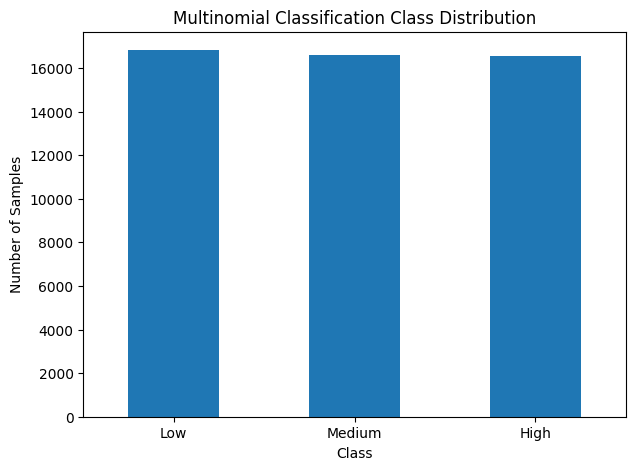


EXPERIMENT 6 COMPLETED


In [3]:
# EXPERIMENT 6
# Multinomial Logistic Regression

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# --------------------------------------------------
# 1. Load Dataset
# --------------------------------------------------

df = pd.read_csv("placement_predict_50k_adjusted.csv")

print("FIRST 5 ROWS")
print(df.head())


# --------------------------------------------------
# 2. Select Numerical Data
# --------------------------------------------------

numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("\nNUMERICAL COLUMNS")
print(numeric_columns)


# --------------------------------------------------
# 3. Select a Continuous Variable
# --------------------------------------------------

# Prefer Salary if available

if "Salary" in df.columns:

    target_source = "Salary"

elif "CGPA" in df.columns: # Choose CGPA if Salary is not available
    target_source = "CGPA"

else:
    # Fallback to the last numerical column if neither Salary nor CGPA is present
    target_source = numeric_columns[-1]


print("\nTARGET SOURCE:", target_source)


# --------------------------------------------------
# 4. Create Three Classes
# --------------------------------------------------

# Divide values into 3 groups:
# 0 = Low
# 1 = Medium
# 2 = High

df["Performance_Class"] = pd.qcut(
    df[target_source],
    q=3,
    labels=[0, 1, 2],
    duplicates="drop"
)


# --------------------------------------------------
# 5. Prepare Features
# --------------------------------------------------

X = df.select_dtypes(
    include=["int64", "float64"]
).copy()

# Remove the original target
if target_source in X.columns:
    X = X.drop(
        columns=[target_source]
    )


# Remove the newly created target if present
if "Performance_Class" in X.columns:
    X = X.drop(
        columns=["Performance_Class"]
    )


y = df["Performance_Class"]


# --------------------------------------------------
# 6. Convert Target
# --------------------------------------------------

y = y.astype(int)


# --------------------------------------------------
# 7. Handle Missing Values
# --------------------------------------------------

imputer = SimpleImputer(
    strategy="median"
)

X = imputer.fit_transform(X)


# --------------------------------------------------
# 8. Train-Test Split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# --------------------------------------------------
# 9. Feature Scaling
# --------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)


# --------------------------------------------------
# 10. Multinomial Logistic Regression
# --------------------------------------------------

model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000
)


# --------------------------------------------------
# 11. Train
# --------------------------------------------------

model.fit(
    X_train,
    y_train
)


# --------------------------------------------------
# 12. Prediction
# --------------------------------------------------

y_pred = model.predict(
    X_test
)

y_probability = model.predict_proba(
    X_test
)


# --------------------------------------------------
# 13. Accuracy
# --------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nACCURACY")
print(accuracy)


# --------------------------------------------------
# 14. Confusion Matrix
# --------------------------------------------------

print("\nCONFUSION MATRIX")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


# --------------------------------------------------
# 15. Classification Report
# --------------------------------------------------

print("\nCLASSIFICATION REPORT")

print(
    classification_report(
        y_test,
        y_pred
    )
)


# --------------------------------------------------
# 16. Probability of Each Class
# --------------------------------------------------

print("\nFIRST 10 PREDICTION PROBABILITIES")

print(
    y_probability[:10]
)


# --------------------------------------------------
# 17. Display Model Classes
# --------------------------------------------------

print("\nMODEL CLASSES")

print(
    model.classes_
)


# --------------------------------------------------
# 18. Visualise Class Distribution
# --------------------------------------------------

plt.figure(figsize=(7, 5))

df["Performance_Class"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.title(
    "Multinomial Classification Class Distribution"
)

plt.xticks(
    [0, 1, 2],
    ["Low", "Medium", "High"],
    rotation=0
)

plt.show()


print("\nEXPERIMENT 6 COMPLETED")